<a href="https://colab.research.google.com/github/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/blob/main/labs/Lab-03_LR_SVC/student_performance_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [79]:

#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)
import time


## Load Dataset

In [80]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Exploratory Data Analysis

In [81]:
# Check Type and info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [82]:
# Check missing values
Missing_values_df = df.isnull().sum()
print("number of missing values:\n", Missing_values_df)


number of missing values:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [83]:
# Check Duplicate values
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)


number of duplicate rows:  (127, 6)


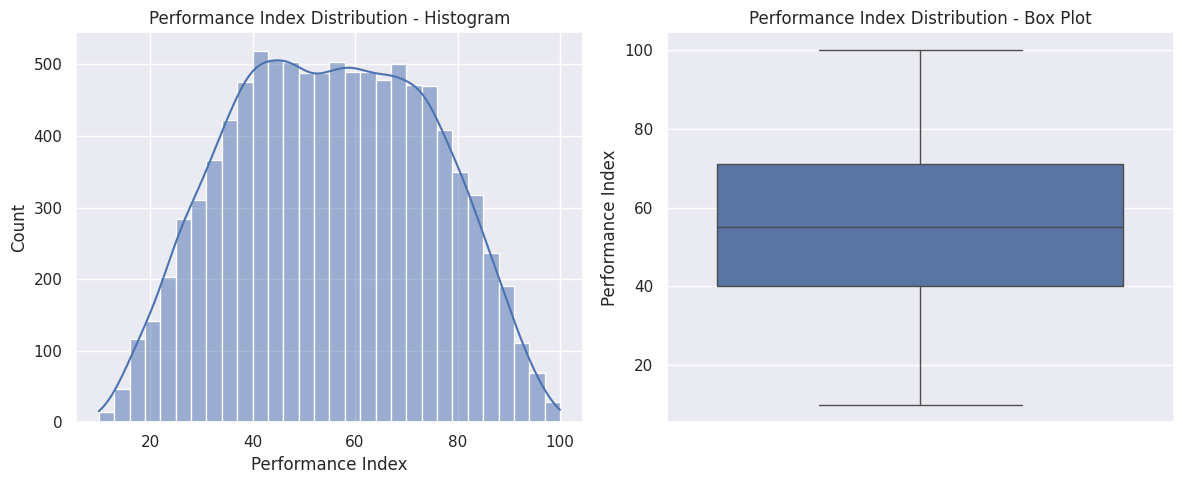

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [84]:
# Visualizing the Hours Studied distribution.

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance Index Distribution - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index Distribution - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the Hours Studied distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [85]:
# Encode categorical columns if any
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Extracurricular Activities"
]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])



In [86]:
# Convert to Dummy Variable


# Convert True/False to 0/1
df_encoded_status = df_encoded.astype(int)

In [87]:
df1 = df_encoded_status.copy()
df1.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


## Visualization

<Axes: >

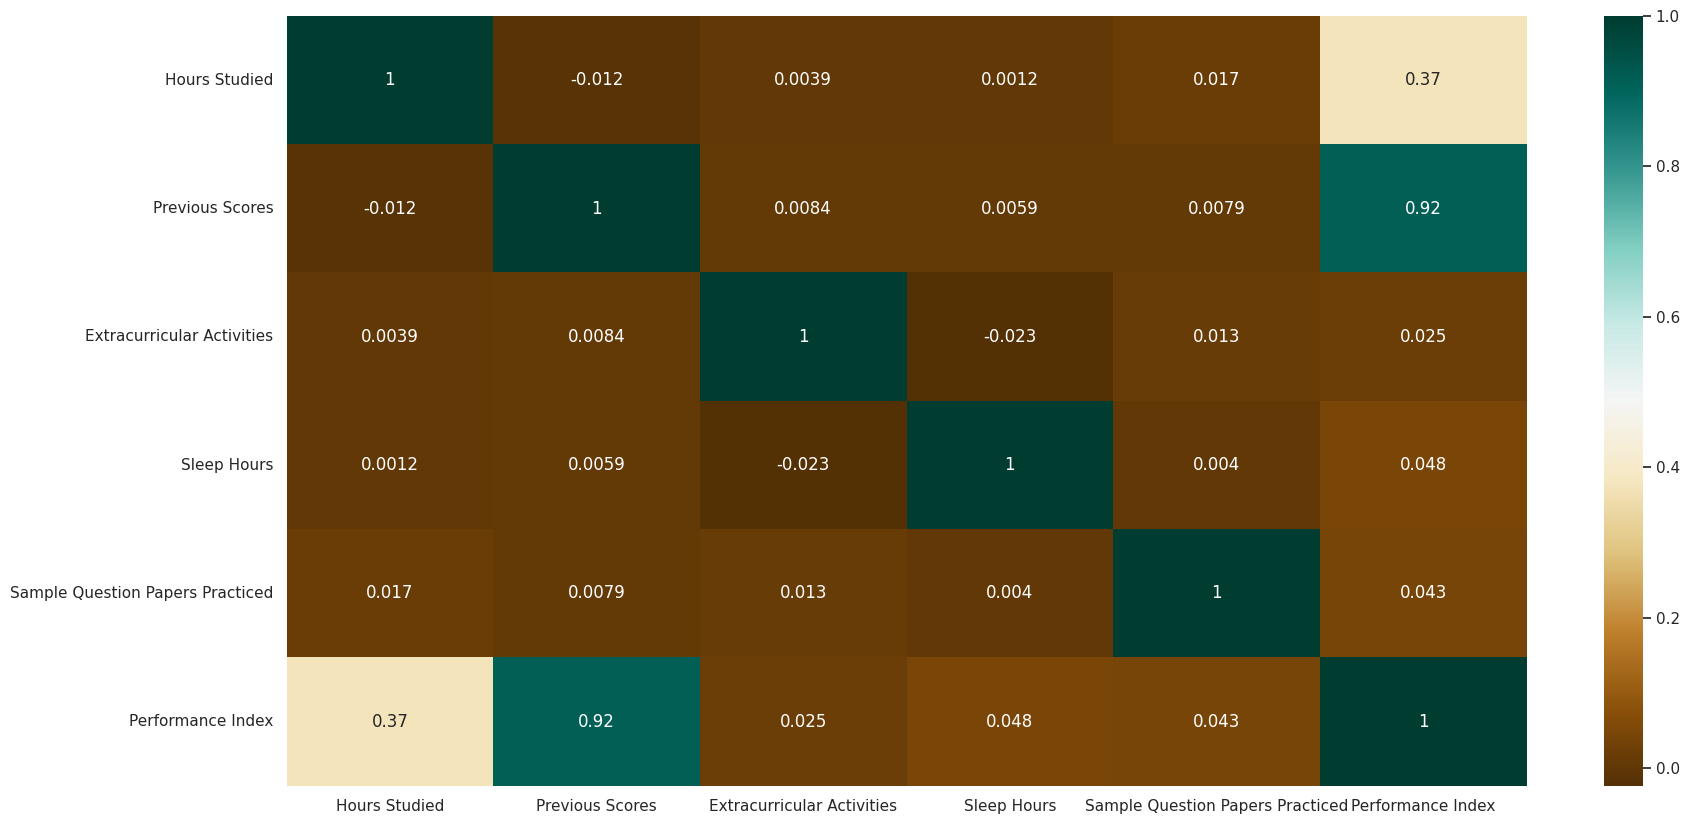

In [88]:
# Scatter plots
# Heatmap

c = df1.corr()
plt.figure(figsize=(20,10))
sns.heatmap(c,cmap="BrBG",annot=True)

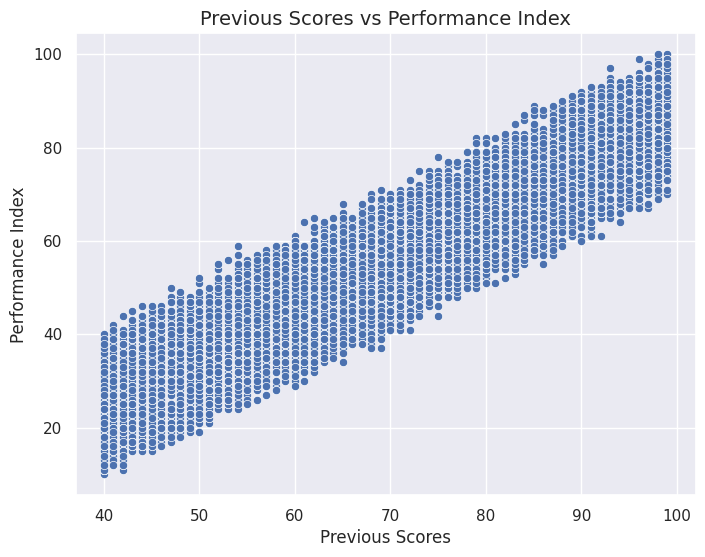

In [89]:
# Examining the relationship between Area and Price.

# Creating a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df1)
plt.title(f"Previous Scores vs Performance Index", fontsize=14)
plt.xlabel("Previous Scores", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Correlation Analysis

In [90]:
# Compute correlation matrix
correlation_matrix = df1.corr()
print("Correlation Matrix:")
print(correlation_matrix.to_string())

Correlation Matrix:
                                  Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  Sample Question Papers Practiced  Performance Index
Hours Studied                          1.000000        -0.012390                    0.003873     0.001245                          0.017463           0.373730
Previous Scores                       -0.012390         1.000000                    0.008369     0.005944                          0.007888           0.915189
Extracurricular Activities             0.003873         0.008369                    1.000000    -0.023284                          0.013103           0.024525
Sleep Hours                            0.001245         0.005944                   -0.023284     1.000000                          0.003990           0.048106
Sample Question Papers Practiced       0.017463         0.007888                    0.013103     0.003990                          1.000000           0.043268
Performance Index         

## Train-Test Split

In [91]:
# Importing necessary libraries.
from sklearn.model_selection import train_test_split # For splitting the dataset.
from sklearn.preprocessing import MinMaxScaler # For Scaling the features.

X = df1.drop(["Performance Index"], axis=1)
y = df1["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
df1.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


## Feature Selection

In [93]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.215e+05
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:28:53   Log-Likelihood:                -14950.
No. Observations:                7000   AIC:                         2.991e+04
Df Residuals:                    6994   BIC:                         2.995e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [94]:
p_values = model.pvalues
significant_features = p_values[p_values < 0.05]
print(significant_features)
nonsignificant_features = p_values[p_values > 0.05]
print(nonsignificant_features)

const                                0.000000e+00
Hours Studied                        0.000000e+00
Previous Scores                      0.000000e+00
Extracurricular Activities           3.326914e-32
Sleep Hours                         5.921877e-225
Sample Question Papers Practiced    2.016842e-106
dtype: float64
Series([], dtype: float64)


In [95]:
# Remove 'const' from the list of significant features
final_feature_names = significant_features.index.drop('const')

# Now filter your original dataframes
X_train_final = X_train[final_feature_names]
X_test_final = X_test[final_feature_names]

In [96]:
X_train_final

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9069,4,99,1,6,1
2603,6,90,1,9,3
7738,8,57,0,6,1
1579,6,92,1,8,7
5058,6,64,1,8,4
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


## Feature Scaling (If needed)

In [97]:
# Applying Feature Scaling.
from sklearn.preprocessing import StandardScaler
# Only numerical features should be scaled.
numeric_vars = ["Hours Studied", "Previous Scores","Sleep Hours", "Sample Question Papers Practiced"]

# Initializing the MinMaxScaler.
# scaler = MinMaxScaler()
scaler = StandardScaler()

# Fitting the MinMaxScaler ONLY to the TRAINING data (X_train) and transforming it.
X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])

# Transforming the Test data ONLY - We do not fit.
X_test[numeric_vars] = scaler.transform(X_test[numeric_vars])

print("--- First 5 Rows of Scaled Training Data ---")
# Displaying Scaled numerical columns for checking.
print(X_train[numeric_vars].head().to_markdown(index=False, numalign="left", stralign="left", floatfmt=".2f"))


#ONLY FOR SVRR
# Scale y
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()


--- First 5 Rows of Scaled Training Data ---
| Hours Studied   | Previous Scores   | Sleep Hours   | Sample Question Papers Practiced   |
|:----------------|:------------------|:--------------|:-----------------------------------|
| -0.38           | 1.70              | -0.32         | -1.26                              |
| 0.39            | 1.18              | 1.45          | -0.56                              |
| 1.16            | -0.73             | -0.32         | -1.26                              |
| 0.39            | 1.29              | 0.86          | 0.83                               |
| 0.39            | -0.32             | 0.86          | -0.22                              |


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [98]:
#Linear Regression

from sklearn.linear_model import LinearRegression

# Initialize the model (fit_intercept=True is the default, so it handles the constant automatically)
lr_model = LinearRegression()

# Fit the model using your scaled features and original target
start_train = time.time()
lr_model.fit(X_train, y_train)
train_time_lr = time.time() - start_train

# Make predictions
start_test = time.time()
lr_predictions = lr_model.predict(X_test)
test_time_lr = time.time() - start_test



In [99]:
#Support Vector Regression

from sklearn.svm import SVR

# Initialize the model (Radial Basis Function kernel is a good default)
svr_model = SVR(kernel='rbf')

# Fit using the SCALED features and SCALED target
start_train = time.time()
svr_model.fit(X_train, y_train_scaled)
train_time_svr = time.time() - start_train

# Make predictions (these will be in the scaled format)
start_test = time.time()
svr_predictions_scaled = svr_model.predict(X_test)
test_time_svr = time.time() - start_test

# Inverse transform predictions back to the original 0-100 Performance Index scale
svr_predictions = scaler_y.inverse_transform(svr_predictions_scaled.reshape(-1, 1)).ravel()

In [100]:
#Decision Trees
from sklearn.tree import DecisionTreeRegressor

# Initialize the model (setting a random_state ensures your results are reproducible)

dt_model = DecisionTreeRegressor(random_state=42)

# Fit the model

start_train = time.time()
dt_model.fit(X_train, y_train)
train_time_dt = time.time() - start_train

# Make predictions
start_test = time.time()
dt_predictions = dt_model.predict(X_test)
test_time_dt = time.time() - start_train

In [101]:
#Random Forests
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

# Fit the model
start_train = time.time()
rf_model.fit(X_train, y_train)
train_time_rf = time.time() - start_train

# Make predictions
start_test = time.time()
rf_predictions = rf_model.predict(X_test)
test_time_rf = time.time() - start_train

In [102]:
#K-Nearest Neighbours
from sklearn.neighbors import KNeighborsRegressor

# Initialize the model (5 neighbors is the standard default)
knn_model = KNeighborsRegressor(n_neighbors=5)

# Fit the model
start_train = time.time()
knn_model.fit(X_train, y_train)
train_time_knn = time.time() - start_train

# Make predictions
start_test = time.time()
knn_predictions = knn_model.predict(X_test)
test_time_knn = time.time() - start_train

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?


---


A Random Forest Regressor predicts a continuous value by combining the outputs of multiple decision tree regressors, which are individual models that estimate a target value by splitting data based on feature conditions down to a final average value at an end node. To build this "forest," the algorithm uses bootstrapping—a statistical technique that creates multiple diverse training datasets by randomly sampling the original data with replacement. Each decision tree is then trained independently on one of these unique bootstrapped datasets and uses a random subset of features for its splits, ensuring the trees learn different patterns rather than memorizing the exact same data. When predicting a new continuous value, the data point is passed through every single tree in the forest, and the final output is calculated by taking the mean (average) of all those individual tree predictions, resulting in a highly accurate and robust continuous estimate.





### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?



---



A K-Nearest Neighbors (KNN) Regressor predicts a continuous output for a new data point by finding the most similar examples in the training data and averaging their target values. Central to this process is "K", a pre-defined number (hyperparameter) that dictates the exact amount of neighboring data points the model should consider. To select these neighbors, the algorithm calculates the mathematical distance—most commonly the Euclidean distance—between the new, unseen data point and every single point in the training dataset, identifying the "K" points that are physically closest to it in the feature space. Once these nearest neighbors are selected, the final predicted value is calculated simply by taking the mean (average) of the continuous target values of those specific K neighbors.



## Visualize Best Model

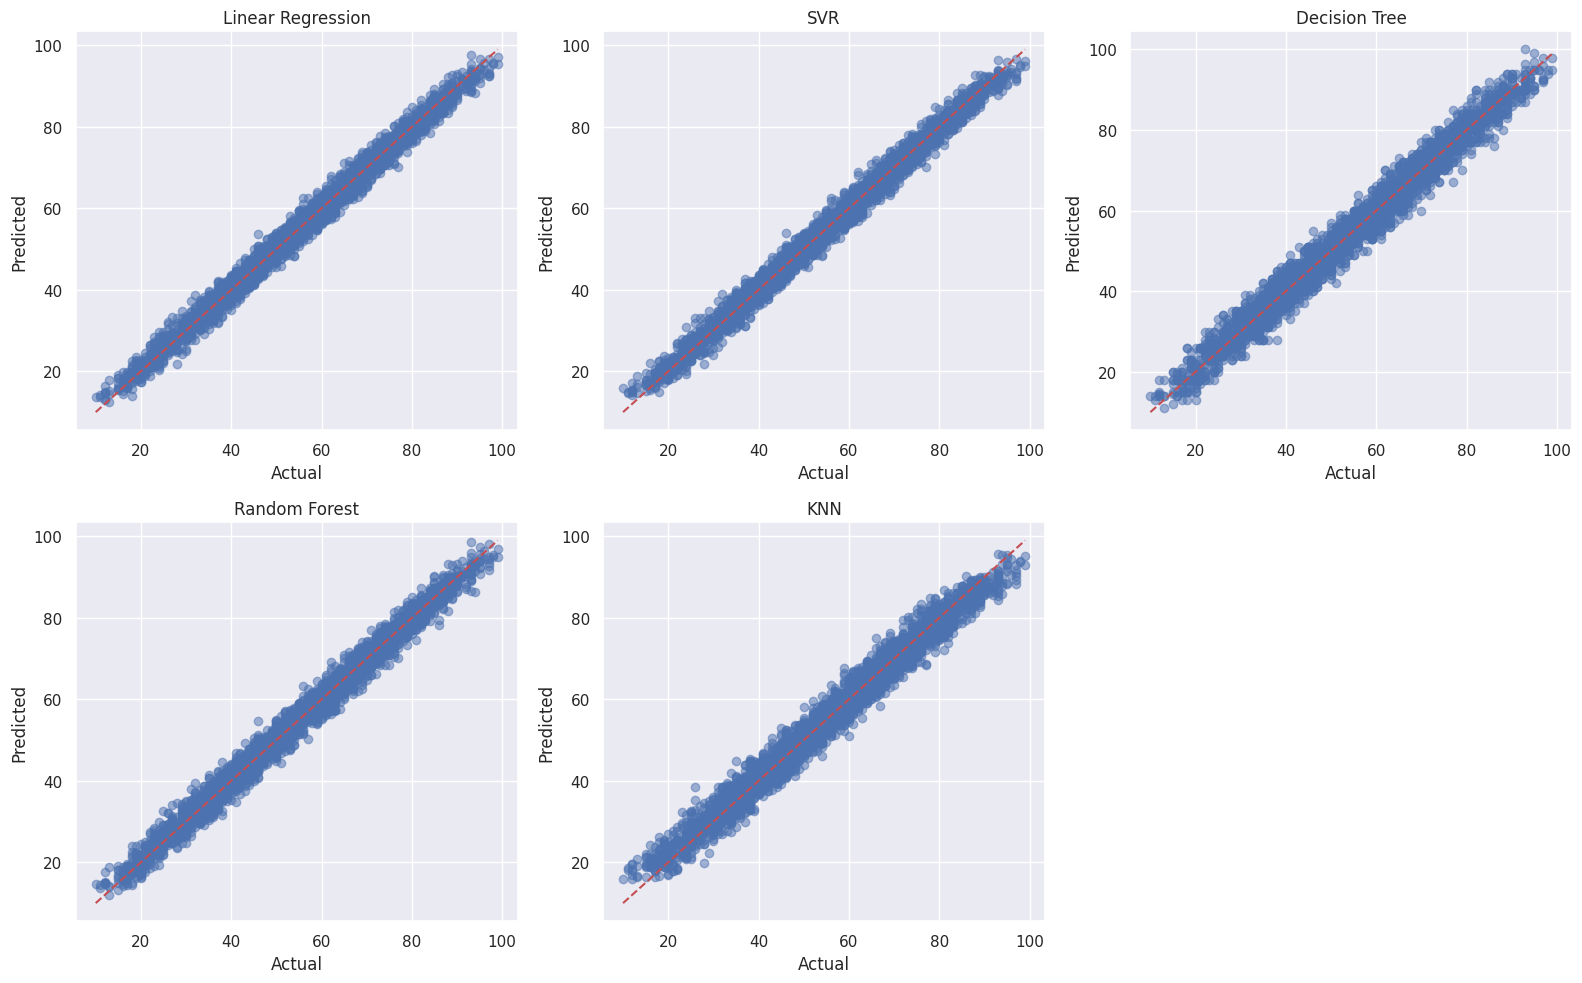

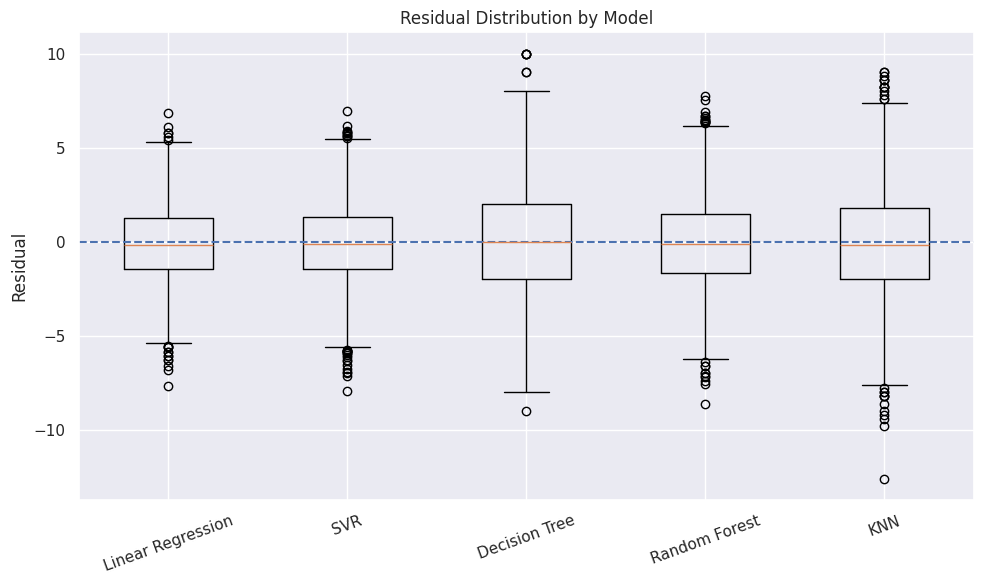

,Model,MAE,RMSE,R2 Score,Training Time,Testing Time
0,Linear Regression,1.6090,2.0166,0.9890,0.0058,0.0019
1,SVR,1.6548,2.0760,0.9884,1.2316,0.3808
2,Decision Tree,2.3592,2.9721,0.9761,0.0276,0.0301
3,Random Forest,1.8318,2.2895,0.9858,1.6813,1.7628
4,KNN,2.3703,2.9616,0.9763,0.0093,0.0391


In [103]:


# 1. Import the libraries
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

# 2. Create a helper function to calculate metrics cleanly
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 4), round(rmse, 4), round(r2, 4)

# 3. Calculate metrics for each model
# (Using the exact variable names from your earlier screenshot)
mae_lr, rmse_lr, r2_lr = get_metrics(y_test, lr_predictions)
mae_svr, rmse_svr, r2_svr = get_metrics(y_test, svr_predictions)
mae_dt, rmse_dt, r2_dt = get_metrics(y_test, dt_predictions)
mae_rf, rmse_rf, r2_rf = get_metrics(y_test, rf_predictions)
mae_knn, rmse_knn, r2_knn = get_metrics(y_test, knn_predictions)

# 4. Construct the final table manually to match your layout
evaluation_data = [
    {"Model": "Linear Regression", "MAE": mae_lr, "RMSE": rmse_lr, "R2 Score": r2_lr, "Training Time": round(train_time_lr, 4), "Testing Time": round(test_time_lr, 4)},
    {"Model": "SVR",               "MAE": mae_svr, "RMSE": rmse_svr, "R2 Score": r2_svr, "Training Time": round(train_time_svr, 4), "Testing Time": round(test_time_svr, 4)},
    {"Model": "Decision Tree",     "MAE": mae_dt, "RMSE": rmse_dt, "R2 Score": r2_dt, "Training Time": round(train_time_dt, 4), "Testing Time": round(test_time_dt, 4)},
    {"Model": "Random Forest",     "MAE": mae_rf, "RMSE": rmse_rf, "R2 Score": r2_rf, "Training Time": round(train_time_rf, 4), "Testing Time": round(test_time_rf, 4)},
    {"Model": "KNN",               "MAE": mae_knn, "RMSE": rmse_knn, "R2 Score": r2_knn, "Training Time": round(train_time_knn, 4), "Testing Time": round(test_time_knn, 4)}
]
pred_dict = {
    "Linear Regression": lr_predictions,
    "SVR": svr_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions,
    "KNN": knn_predictions
}

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.ravel()

for i, (name, preds) in enumerate(pred_dict.items()):
    axes[i].scatter(y_test, preds, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(name)
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

if len(pred_dict) < len(axes):
    for j in range(len(pred_dict), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

residual_data = pd.DataFrame({
    "Linear Regression": y_test - lr_predictions,
    "SVR": y_test - svr_predictions,
    "Decision Tree": y_test - dt_predictions,
    "Random Forest": y_test - rf_predictions,
    "KNN": y_test - knn_predictions
})

plt.figure(figsize=(10,6))
plt.boxplot([residual_data[col] for col in residual_data.columns], tick_labels=residual_data.columns)
plt.axhline(0, linestyle='--')
plt.title("Residual Distribution by Model")
plt.ylabel("Residual")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
# 5. Convert to a DataFrame and display as a styled HTML table
results_df = pd.DataFrame(evaluation_data)
display(results_df)

## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---